# Vision Transformer for Cats vs Dogs Classification

In [ ]:
# Install required packages
!pip install -q timm albumentations numpy pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/363.4 MB 169.5 MB/s eta 0:00:02

In [3]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Using device: cuda


## 2. Data Loading and Preprocessing

We'll create a custom Dataset class for loading the cats vs dogs images.

In [ ]:
class CatsDogsDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = plt.imread(img_path)
        
        # Convert grayscale to RGB if needed
        if len(image.shape) == 2:
            image = np.stack([image] * 3, axis=2)
        
        # Make sure image is in RGB format
        if image.shape[2] == 4:
            image = image[:, :, :3]
            
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        label = self.labels[idx]
        return image, label

# Define image transformations
def get_transforms(is_training=True):
    if is_training:
        return A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Entire ImageNet 
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [7]:
# Prepare data paths and labels
def prepare_data(data_dir='/kaggle/input/microsoft-catsvsdogs-dataset/PetImages/'):
    image_paths = []
    labels = []
    
    # Load cat images (label 0)
    cat_dir = os.path.join(data_dir, 'Cat')
    for img_name in os.listdir(cat_dir):
        if img_name.endswith('.jpg'):
            img_path = os.path.join(cat_dir, img_name)
            try:
                # Try to open the image to ensure it's valid
                with open(img_path, 'rb') as f:
                    img = plt.imread(img_path)
                    image_paths.append(img_path)
                    labels.append(0)
            except:
                continue
    
    # Load dog images (label 1)
    dog_dir = os.path.join(data_dir, 'Dog')
    for img_name in os.listdir(dog_dir):
        if img_name.endswith('.jpg'):
            img_path = os.path.join(dog_dir, img_name)
            try:
                # Try to open the image to ensure it's valid
                with open(img_path, 'rb') as f:
                    img = plt.imread(img_path)
                    image_paths.append(img_path)
                    labels.append(1)
            except:
                continue
    
    return np.array(image_paths), np.array(labels)

# Load and split the data
image_paths, labels = prepare_data()
print(f"Total images found: {len(image_paths)}")

# Split data into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_paths, labels, test_size=0.15, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Create datasets
train_dataset = CatsDogsDataset(X_train, y_train, transform=get_transforms(is_training=True))
val_dataset = CatsDogsDataset(X_val, y_val, transform=get_transforms(is_training=False))
test_dataset = CatsDogsDataset(X_test, y_test, transform=get_transforms(is_training=False))

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Total images found: 24998
Training samples: 18060
Validation samples: 3188
Test samples: 3750


## 3. Vision Transformer Model Setup

We'll use a pre-trained Vision Transformer model from the `timm` library and modify it for our binary classification task. We'll use the `vit_base_patch16_224` architecture, which:
- Uses 16x16 patch size
- Takes 224x224 input images
- Has the base ViT architecture with 12 transformer layers

In [8]:
# Load pre-trained ViT model
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

## 4. Model Training

In [ ]:
# Training functions
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        progress_bar.set_postfix({'loss': total_loss / (progress_bar.n + 1),'acc': 100. * correct / total})
    
    return total_loss / len(train_loader), 100. * correct / total

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(val_loader), 100. * correct / total

In [10]:
# Training loop
num_epochs = 10
best_val_acc = 0
patience = 3
patience_counter = 0

# Lists to store metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    # Learning rate scheduling
    scheduler.step()
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print('Early stopping triggered')
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))


Epoch 1/10


Training:   0%|          | 0/565 [00:00<?, ?it/s]

Train Loss: 0.0298, Train Acc: 98.92%
Val Loss: 0.0127, Val Acc: 99.62%

Epoch 2/10


Training:   0%|          | 0/565 [00:00<?, ?it/s]

Train Loss: 0.0100, Train Acc: 99.65%
Val Loss: 0.0191, Val Acc: 99.53%

Epoch 3/10


Training:   0%|          | 0/565 [00:00<?, ?it/s]

Train Loss: 0.0078, Train Acc: 99.76%
Val Loss: 0.0197, Val Acc: 99.40%

Epoch 4/10


Training:   0%|          | 0/565 [00:00<?, ?it/s]

Train Loss: 0.0061, Train Acc: 99.77%
Val Loss: 0.0218, Val Acc: 99.59%
Early stopping triggered


<All keys matched successfully>

## 5. Model Evaluation

Testing:   0%|          | 0/118 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Test Accuracy: 99.28%


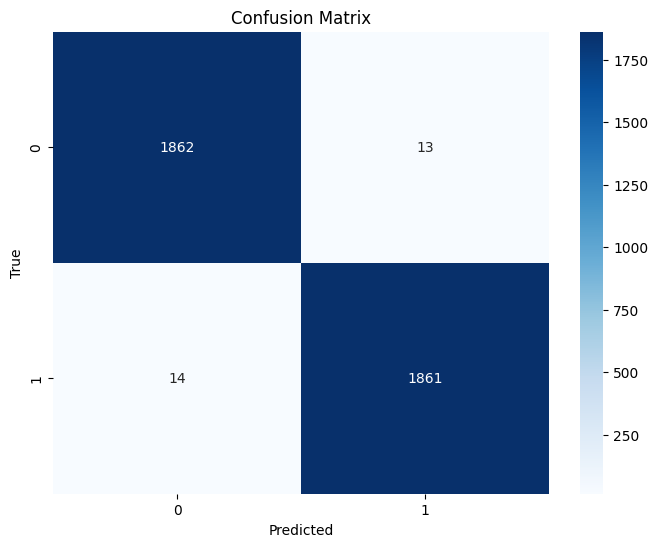


Classification Report:
              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1875
         Dog       0.99      0.99      0.99      1875

    accuracy                           0.99      3750
   macro avg       0.99      0.99      0.99      3750
weighted avg       0.99      0.99      0.99      3750



In [ ]:
# Evaluate on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate and print metrics
test_acc = (all_preds == all_labels).mean() * 100
print(f'\nTest Accuracy: {test_acc:.2f}%')

# Generate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print classification report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))

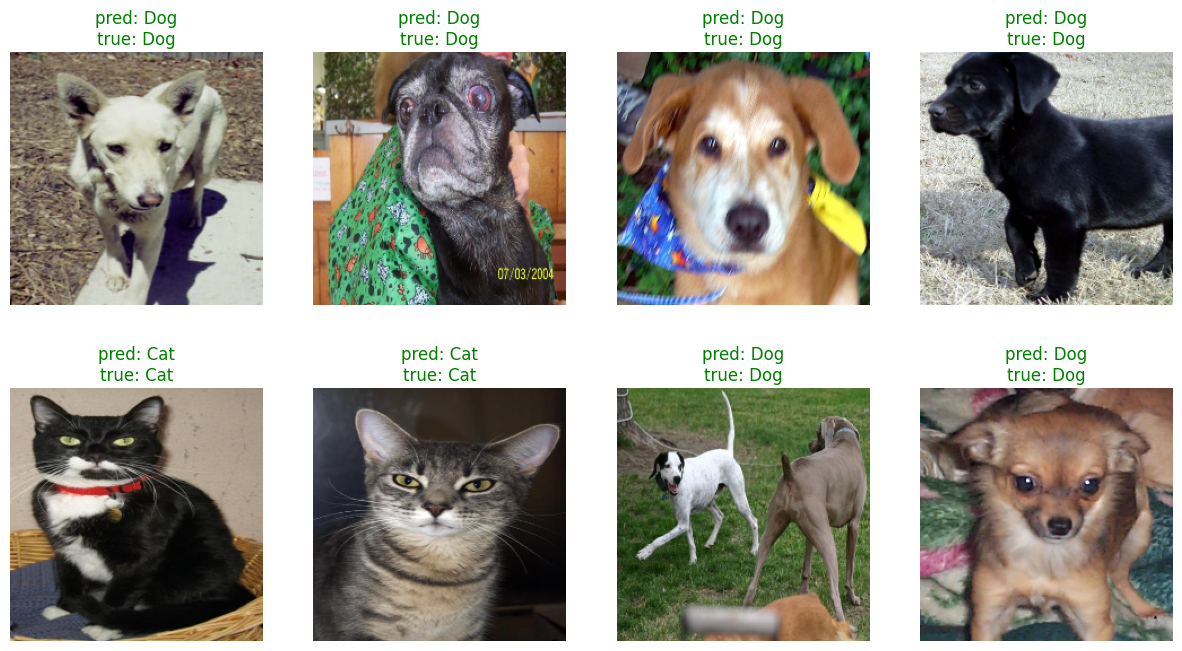

In [13]:
# Visualize some predictions
def visualize_predictions(model, test_loader, num_images=8):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 8))
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            for j in range(images.size()[0]):
                if images_so_far >= num_images:
                    return
                
                images_so_far += 1
                ax = plt.subplot(2, 4, images_so_far)
                ax.axis('off')
                ax.set_title(f'pred: {("Cat", "Dog")[preds[j]]}\ntrue: {("Cat", "Dog")[labels[j]]}',
                           color=('red' if preds[j] != labels[j] else 'green'))
                
                # Denormalize image
                img = images[j].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                plt.imshow(img)
                
                if images_so_far >= num_images:
                    break

visualize_predictions(model, test_loader)
plt.show()